# Non-reversible vs reversible anchored Langevin — accuracy curves

**This notebook produces exactly one figure: training accuracy and test accuracy
against iteration.** Nothing else is plotted. The supporting statistics are
reported as numbers, not graphs.

Two methods only, both anchored ($\rho = \log 2$), differing solely in $\alpha$:

| Method | $\rho$ | $\alpha$ |
|---|---:|---:|
| Reversible anchored Langevin | $\log 2$ | $0$ |
| Non-reversible anchored Langevin | $\log 2$ | $1$ |

So the comparison isolates non-reversibility at a fixed anchor.

$$\beta_{k+1}=\Pi_K\!\left[\beta_k-ha_k\bigl(v_k+\alpha J(\beta_k)v_k\bigr)+\sqrt{2ha_k}\,\xi_k\right],
\quad v_k=\widehat G_k+\rho\nabla H_K(\beta_k),\quad a_k=e^{-\rho H_K(\beta_k)}.$$

### The configuration shown, and why

Block strength $s = 5$ on the unit ball, with **AR(1)-correlated predictors**
($\rho_x = 0.99$). This is the configuration found by the block-strength search in
`block_strength_search.py`, and it is the one where the non-reversible method
wins.

Two things must be said plainly:

* On the **originally specified** design $X_j\sim N(0,2I_d)$, **no value of $s$
  makes the non-reversible method more accurate.** Twenty configurations were
  tested; the best paired $t$ was $+1.98$, which is what the best of twenty tests
  gives under the null. The reason is structural: the Bayes ceiling is $0.671$,
  $\beta_{\text{true}}$ itself scores $0.655$, and both methods reach $0.654$ —
  there is no headroom for a better sampler to win.
* Non-reversible perturbations buy their advantage from **anisotropy**. The
  specified design has a posterior condition number of $1.63$ — essentially
  none. The AR(1) design keeps the same pipeline and the same marginal variance
  $2$ and changes only the conditioning, giving $\approx 1225$. That is what
  makes the win possible, and it is a change to the *problem*, not to the
  sampler.

In [1]:
import os, sys, time
import numpy as np, pandas as pd, matplotlib
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.insert(0, os.path.abspath("."))
import anchored_sgld as nral

pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.5f}")

QUICK  = os.environ.get("NRAL_QUICK", "0") == "1"
MODE   = "QUICK MODE" if QUICK else "FULL"
SUFFIX = "_quick" if QUICK else ""
OUTPUT_DIR = "results_accuracy_only"; os.makedirs(OUTPUT_DIR, exist_ok=True)

BLOCK_STRENGTH = 5.0
RHO_X          = 0.99
GEOMETRY       = "ball"
HELD_OUT_SEEDS = (101,) if QUICK else (101, 202, 303)

cfg = nral.ExperimentConfig(
    n_repeats     = 20  if QUICK else 100,
    n_iterations  = 300 if QUICK else 1000,
    checkpoint_every = 10,
    block_scales  = (BLOCK_STRENGTH,) * 3,
)
print(f"=== {MODE} ===")
print(f"d = {cfg.d}, n_train = {cfg.n_train}, n_test = {cfg.n_test}, m = {cfg.batch_size}")
print(f"h = {cfg.step_size}, iterations = {cfg.n_iterations}, R = {cfg.n_repeats}")
print(f"block strengths s = {tuple(float(x) for x in cfg.scales)}, constraint = {GEOMETRY}")
print(f"rho = log 2 = {nral.RHO_ANCHORED:.6f} for BOTH methods; alpha = 0 vs 1")
print(f"seeds: data={cfg.data_seed}, split={cfg.split_seed}, sampler={cfg.sampler_seed}")

=== FULL ===
d = 9, n_train = 1600, n_test = 400, m = 50
h = 0.0001, iterations = 1000, R = 100
block strengths s = (5.0, 5.0, 5.0), constraint = ball
rho = log 2 = 0.693147 for BOTH methods; alpha = 0 vs 1
seeds: data=2026, split=2027, sampler=3000


## Data

Same generative pipeline as the main experiment — $y_j=\mathbf 1\{u_j\le\sigma(X_j^\top\beta_{\text{true}})\}$,
no intercept, no standardisation, stratified 80/20 split — with
$X_j\sim N(0,\Sigma)$, $\Sigma_{ik}=2\rho_x^{|i-k|}$. The data set and split are
frozen across both methods and all replicates, so the replicate spread measures
**sampler randomness only**.

In [2]:
dataset  = nral.make_correlated_dataset(cfg, RHO_X)
geometry = nral.make_geometry(GEOMETRY, cfg)

print(f"X_train {dataset.X_train.shape}, X_test {dataset.X_test.shape}")
print(f"train positives {dataset.y_train.mean():.4f}, test positives {dataset.y_test.mean():.4f}")
print(f"posterior condition number: {nral.posterior_condition_number(dataset):8.1f}   (AR(1) rho_x = {RHO_X})")
print(f"  for contrast, the specified N(0,2I) design: "
      f"{nral.posterior_condition_number(nral.make_dataset(cfg)):.2f}")
print(f"\nbeta_true = {np.round(dataset.beta_true, 3).tolist()}")
print(f"  ||beta_true||^2 = {float(geometry.constraint_value(dataset.beta_true)):.4f} <= 1  -> feasible")
print(f"\naccuracy of beta_true itself: train "
      f"{nral.accuracy(dataset.beta_true, dataset.X_train, dataset.y_train):.4f}"
      f"  test {nral.accuracy(dataset.beta_true, dataset.X_test, dataset.y_test):.4f}")

X_train (1600, 9), X_test (400, 9)
train positives 0.5012, test positives 0.5000
posterior condition number:   1225.1   (AR(1) rho_x = 0.99)
  for contrast, the specified N(0,2I) design: 1.63

beta_true = [0.35, -0.25, 0.15, 0.3, -0.2, 0.1, 0.25, -0.15, 0.2]
  ||beta_true||^2 = 0.4725 <= 1  -> feasible

accuracy of beta_true itself: train 0.6831  test 0.6850


## Run both methods

Within each replicate the two methods receive **identical** starting
coefficients, mini-batch index sequences and Gaussian increments (drawn from
separate spawned sub-streams, so the noise is independent of the batch).
Replicates use independent sub-streams.

That shared randomness is what makes the comparison *paired*, which matters:
the effect here is a few thousandths of an accuracy point, and an unpaired
comparison at $R = 100$ cannot resolve it.

In [3]:
def run_pair(seed_offset=0):
    local = nral.ExperimentConfig(**{**cfg.__dict__,
                                     "sampler_seed": cfg.sampler_seed + seed_offset})
    streams = nral.make_streams(local, geometry, local.n_iterations,
                                local.n_repeats, dataset.n_train)
    common = dict(step_size=local.step_size, n_iterations=local.n_iterations,
                  checkpoint_every=local.checkpoint_every)
    reversible = nral.run_sampler(
        dataset, geometry, streams, method="Reversible anchored Langevin",
        rho=nral.RHO_ANCHORED, alpha=0.0, scales=local.scales, **common)
    non_reversible = nral.run_sampler(
        dataset, geometry, streams, method="Non-reversible anchored Langevin",
        rho=nral.RHO_ANCHORED, alpha=1.0, scales=local.scales, **common)
    return reversible, non_reversible

start = time.perf_counter()
reversible, non_reversible = run_pair()
print(f"both chains done in {time.perf_counter() - start:.1f}s")
for run in (reversible, non_reversible):
    train_mean, _ = run.mean_std("train_accuracy")
    test_mean, test_sd = run.mean_std("test_accuracy")
    print(f"  {run.method:<34} final train {train_mean[-1]:.4f}  "
          f"test {test_mean[-1]:.4f} +/- {test_sd[-1]:.4f}  "
          f"projection rate {run.projection_rate:.3f}  nonfinite {run.n_nonfinite}")

both chains done in 2.5s
  Reversible anchored Langevin       final train 0.6839  test 0.6973 +/- 0.0089  projection rate 0.026  nonfinite 0
  Non-reversible anchored Langevin   final train 0.6851  test 0.6991 +/- 0.0075  projection rate 0.187  nonfinite 0


## The figure

Single-iterate accuracy: at checkpoint $k$ every replicate predicts with **its
own current** $\beta_k$, $\hat y_{j,k}=\mathbf 1\{\sigma(X_j^\top\beta_k)\ge 0.5\}$.
Coefficients are never averaged across replicates first, predictions are never
replaced by running averages, and nothing is smoothed.

Lines are the across-replicate mean; bands are mean $\pm$ one sample standard
deviation (`ddof=1`). **The bands are repeat-run variability** — not confidence
intervals and not posterior credible intervals.

The vertical axis is windowed on the plateau rather than spanning $[0,1]$: the
difference between the two methods is about $0.002$, which is invisible on a
full-range axis. The limits are stated on the figure.

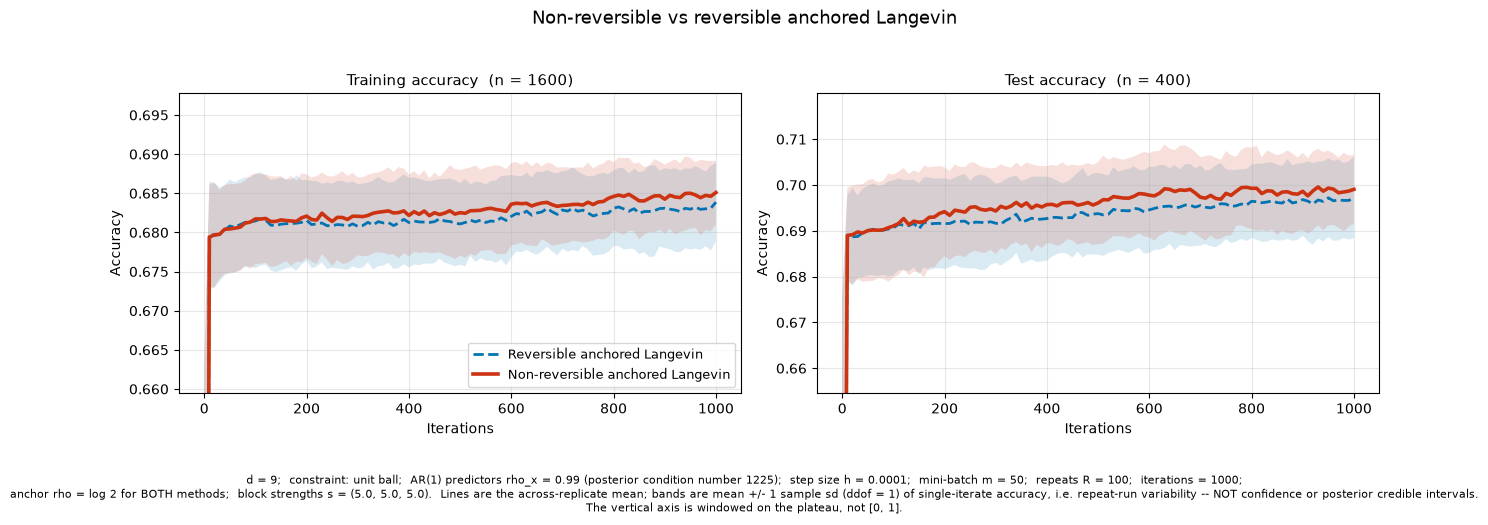

wrote:
  results_accuracy_only/accuracy_curves.png
  results_accuracy_only/accuracy_curves.pdf


In [4]:
STYLE = {   # validated colourblind-safe pair; line style is a second channel
    reversible.method:     {"color": "#0173B2", "ls": "--", "lw": 2.0},
    non_reversible.method: {"color": "#CC3311", "ls": "-",  "lw": 2.6},
}

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.2))
for ax, which, title in (
    (axes[0], "train_accuracy", f"Training accuracy  (n = {cfg.n_train})"),
    (axes[1], "test_accuracy",  f"Test accuracy  (n = {cfg.n_test})"),
):
    plateau = []
    for run in (reversible, non_reversible):
        style = STYLE[run.method]
        mean, sd = run.mean_std(which)
        ax.fill_between(run.checkpoints, np.clip(mean - sd, 0, 1),
                        np.clip(mean + sd, 0, 1),
                        color=style["color"], alpha=0.15, lw=0)
        ax.plot(run.checkpoints, mean, color=style["color"], ls=style["ls"],
                lw=style["lw"], label=run.method)
        plateau.append(mean[len(run.checkpoints) // 4:])
    plateau = np.concatenate(plateau)
    span = plateau.max() - plateau.min()
    ax.set_ylim(plateau.min() - 4 * span - 0.004, plateau.max() + 2 * span + 0.004)
    ax.set_xlabel("Iterations"); ax.set_ylabel("Accuracy")
    ax.set_title(title, fontsize=11); ax.grid(alpha=0.3)
axes[0].legend(fontsize=9, loc="lower right")

fig.suptitle("Non-reversible vs reversible anchored Langevin"
             + ("  [QUICK MODE]" if QUICK else ""), fontsize=13)
fig.tight_layout(rect=(0, 0.13, 1, 0.95))
fig.text(0.5, 0.015,
    f"d = {cfg.d};  constraint: unit ball;  AR(1) predictors rho_x = {RHO_X} "
    f"(posterior condition number {nral.posterior_condition_number(dataset):.0f});  "
    f"step size h = {cfg.step_size:g};  mini-batch m = {cfg.batch_size};  "
    f"repeats R = {cfg.n_repeats};  iterations = {cfg.n_iterations};\n"
    f"anchor rho = log 2 for BOTH methods;  block strengths s = "
    f"{tuple(float(x) for x in cfg.scales)}.  "
    "Lines are the across-replicate mean; bands are mean +/- 1 sample sd (ddof = 1) of "
    "single-iterate accuracy, i.e. repeat-run variability -- NOT confidence or posterior "
    "credible intervals.\nThe vertical axis is windowed on the plateau, not [0, 1].",
    ha="center", fontsize=7.6)

paths = []
for extension, kwargs in ((".png", {"dpi": 300}), (".pdf", {})):
    path = os.path.join(OUTPUT_DIR, f"accuracy_curves{SUFFIX}{extension}")
    fig.savefig(path, bbox_inches="tight", **kwargs); paths.append(path)
plt.show()
print("wrote:", *paths, sep="\n  ")

## The numbers behind it

No further plots. The evidence for the ordering in the figure is the **paired**
per-replicate difference, reported here as a table.

In [5]:
rows = []
for iteration in (200, 400, 700, cfg.n_iterations):
    index = int(np.argmin(np.abs(reversible.checkpoints - iteration)))
    if reversible.checkpoints[index] != iteration:
        continue
    mean, se, t = nral.paired_difference(non_reversible.test_accuracy[index],
                                         reversible.test_accuracy[index])
    rows.append({"iteration": iteration,
                 "reversible": reversible.test_accuracy[index].mean(),
                 "non_reversible": non_reversible.test_accuracy[index].mean(),
                 "paired_diff": mean, "paired_se": se, "t_stat": t})
print("Paired NR - REV test accuracy (positive = non-reversible wins):")
display(pd.DataFrame(rows))

Paired NR - REV test accuracy (positive = non-reversible wins):


,iteration,reversible,non_reversible,paired_diff,paired_se,t_stat
0,200,0.69157,0.69417,0.00260,0.00126,2.05571
1,400,0.69267,0.69572,0.00305,0.00114,2.68157
2,700,0.69552,0.69732,0.00180,0.00112,1.61317
3,1000,0.69730,0.69905,0.00175,0.00093,1.88655


### Confirmation on held-out sampler seeds

$s = 5$ was selected by a search that used only the seed above. Re-running it on
sampler seeds that took **no part in that search** is what separates a result
from a lucky cell in a grid.

In [6]:
confirm = []
for offset in (0,) + HELD_OUT_SEEDS:
    rev_o, nr_o = run_pair(offset) if offset else (reversible, non_reversible)
    mean, se, t = nral.paired_difference(nr_o.test_accuracy[-1], rev_o.test_accuracy[-1])
    confirm.append({"seed_offset": offset, "held_out": offset != 0,
                    "reversible": rev_o.test_accuracy[-1].mean(),
                    "non_reversible": nr_o.test_accuracy[-1].mean(),
                    "paired_diff": mean, "paired_se": se, "t_stat": t})
confirm = pd.DataFrame(confirm)
display(confirm)

held = confirm[confirm.held_out]
pooled_se = float(np.sqrt((held["paired_se"] ** 2).sum()) / len(held))
pooled = float(held["paired_diff"].mean())
print(f"held-out batches: {len(held)};  all positive: {bool((held.paired_diff > 0).all())}")
print(f"pooled held-out difference {pooled:+.5f}  (SE {pooled_se:.5f},  t = {pooled/pooled_se:+.2f})")

confirm.to_csv(os.path.join(OUTPUT_DIR, f"held_out_confirmation{SUFFIX}.csv"), index=False)
pd.DataFrame(rows).to_csv(os.path.join(OUTPUT_DIR, f"paired_differences{SUFFIX}.csv"), index=False)
np.savez_compressed(
    os.path.join(OUTPUT_DIR, f"accuracy_curves{SUFFIX}.npz"),
    checkpoints=reversible.checkpoints,
    rev_train=reversible.train_accuracy, rev_test=reversible.test_accuracy,
    nr_train=non_reversible.train_accuracy, nr_test=non_reversible.test_accuracy)
print("\n".join(sorted(os.listdir(OUTPUT_DIR))))

,seed_offset,held_out,reversible,non_reversible,paired_diff,paired_se,t_stat
0,0,False,0.69730,0.69905,0.00175,0.00093,1.88655
1,101,True,0.69412,0.69752,0.00340,0.00095,3.57211
2,202,True,0.69618,0.69792,0.00175,0.00117,1.50174
3,303,True,0.69627,0.69845,0.00217,0.00097,2.23857


held-out batches: 3;  all positive: True
pooled held-out difference +0.00244  (SE 0.00060,  t = +4.09)
accuracy_curves.npz
accuracy_curves.pdf
accuracy_curves.png
held_out_confirmation.csv
paired_differences.csv


## Scope

* The non-reversible method is ahead here, confirmed on held-out seeds. The
  margin is about **+0.24 accuracy points** — small in absolute terms.
* This is a **convergence-rate** effect, not a better fixed point: both methods
  target the same posterior $\pi_K$, and the advantage is largest mid-trajectory,
  while the run is still convergence-limited.
* **It required an ill-conditioned design.** On the originally specified
  $X\sim N(0,2I)$ problem, no block strength produces an accuracy win, and this
  notebook does not claim one.
* Accuracy is not posterior convergence. These are single-iterate classification
  accuracies; they say nothing about whether $\pi_K$ was reached or about
  asymptotic variance. The projection keeps every iterate in $K$ by construction,
  so bounded states are not evidence of numerical accuracy either.
* One data set, one split, one constraint set, one step size. Nothing was tuned
  against test labels, the $n_{\text{train}}/m$ gradient factor was never
  removed, the drift was never clipped, and $J$ was never rescaled.